In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_hub as hub

/Users/adithya/Development/adithyasean/computer-vision/.venv/lib/python3.12/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
tf.__version__     # check tesor flow version

'2.21.0'

In [3]:
tfds.list_builders() # check for the avilable datasets inside tensor_flow

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asimov_v2_constraints_with_rationale',
 'asimov_v2_constraints_without_rationale',
 'asimov_v2_injuries',
 'asimov_v2_videos',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkel

In [4]:
(train_data, validation_data, test_data), metadata = tfds.load(
'imdb_reviews',
split=['train[0%:80%]', 'train[80%:90%]', 'train[90%:100%]'],
with_info=True,
as_supervised=True,)  # create 03 datasets, for training, testing and validation - Training - 80% from total dataset, Testing - remaining 20% from the total dataset,  validation, 90% from the quotq of 80% allocated for training

In [5]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [6]:
train_examples_batch, train_labels_batch = next(iter(train_data.batch(2).take(1))) #read  10 user-reviews. You need to iterate in reading those, cannot be read directly.
train_examples_batch

<tf.Tensor: shape=(2,), dtype=string, numpy=
array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell a

In [7]:
train_labels_batch

<tf.Tensor: shape=(2,), dtype=int64, numpy=array([0, 0])>

In [8]:
pretrained_model = "https://kaggle.com/models/google/gnews-swivel/frameworks/TensorFlow2/variations/tf2-preview-20dim/versions/1"
hub_layer = hub.KerasLayer(pretrained_model, input_shape=[], dtype=tf.string, trainable=False)  # pre-trained neural network to convert encode text reviews to numerical vectors


In [9]:
hub_layer(train_examples_batch[:2]) # encoded view of the frist two review feedbacks

<tf.Tensor: shape=(2, 20), dtype=float32, numpy=
array([[ 1.765786  , -3.882232  ,  3.9134233 , -1.5557289 , -3.3362343 ,
        -1.7357955 , -1.9954445 ,  1.2989551 ,  5.081598  , -1.1041286 ,
        -2.0503852 , -0.72675157, -0.65675956,  0.24436149, -3.7208383 ,
         2.0954835 ,  2.2969332 , -2.0689783 , -2.9489717 , -1.1315987 ],
       [ 1.8804485 , -2.5852382 ,  3.4066997 ,  1.0982676 , -4.056685  ,
        -4.891284  , -2.785554  ,  1.3874227 ,  3.8476458 , -0.9256538 ,
        -1.896706  ,  1.2113281 ,  0.11474707,  0.76209456, -4.8791065 ,
         2.906149  ,  4.7087674 , -2.3652055 , -3.5015898 , -1.6390051 ]],
      dtype=float32)>

In [10]:
train_examples_batch[:2]

<tf.Tensor: shape=(2,), dtype=string, numpy=
array([b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.",
       b'I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell a

In [11]:
model = tf.keras.Sequential()
model.add(hub_layer) # input layer is the encoded output from tensor_flow hub neural network
model.add(tf.keras.layers.Dense(16, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.001)))
model.add(tf.keras.layers.Dropout(0.5))
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
model.summary()


Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 keras_layer (KerasLayer)    (None, 20)                400020    


 dense (Dense)               (None, 16)                336       


...

 dense_1 (Dense)             (None, 1)                 17        


Total params: 400373 (1.53 MB)


Trainable params: 353 (1.38 KB)


Non-trainable params: 400020 (1.53 MB)


_________________________________________________________________


In [12]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])  # back_prop configuration

In [13]:
history = model.fit(train_data.shuffle(10000).batch(512),
         epochs=20,
         validation_data=validation_data.batch(512),
         verbose=1) #get ready maximum buffer or 10000 record for training purpose and shuffle them to avoid overfitting. After, feed block sizes of 512 (to prevent RAM memory overflow)for training purposes from the suffled content. verbose will define the o/p results taking place in training phase.
                    # usually, batch sizes are defined as series of 32, 64,128, 256, 512.... More it become big, model maturity is high, but should be managiable to computer HW and shiuld be smaller than the total dataset size

Epoch 1/20


 1/40 [..............................] - ETA: 9s - loss: 1.0402 - accuracy: 0.4805

 6/40 [===>..........................] - ETA: 0s - loss: 1.0090 - accuracy: 0.4746

12/40 [========>.....................] - ETA: 0s - loss: 0.9573 - accuracy: 0.4780

18/40 [============>.................] - ETA: 0s - loss: 0.9249 - accuracy: 0.4817

...

19/40 [=============>................] - ETA: 0s - loss: 0.6091 - accuracy: 0.6854

25/40 [=================>............] - ETA: 0s - loss: 0.6098 - accuracy: 0.6841

31/40 [======================>.......] - ETA: 0s - loss: 0.6095 - accuracy: 0.6839

37/40 [==========================>...] - ETA: 0s - loss: 0.6092 - accuracy: 0.6848

40/40 [==============================] - 0s 10ms/step - loss: 0.6100 - accuracy: 0.6834 - val_loss: 0.5826 - val_accuracy: 0.7032


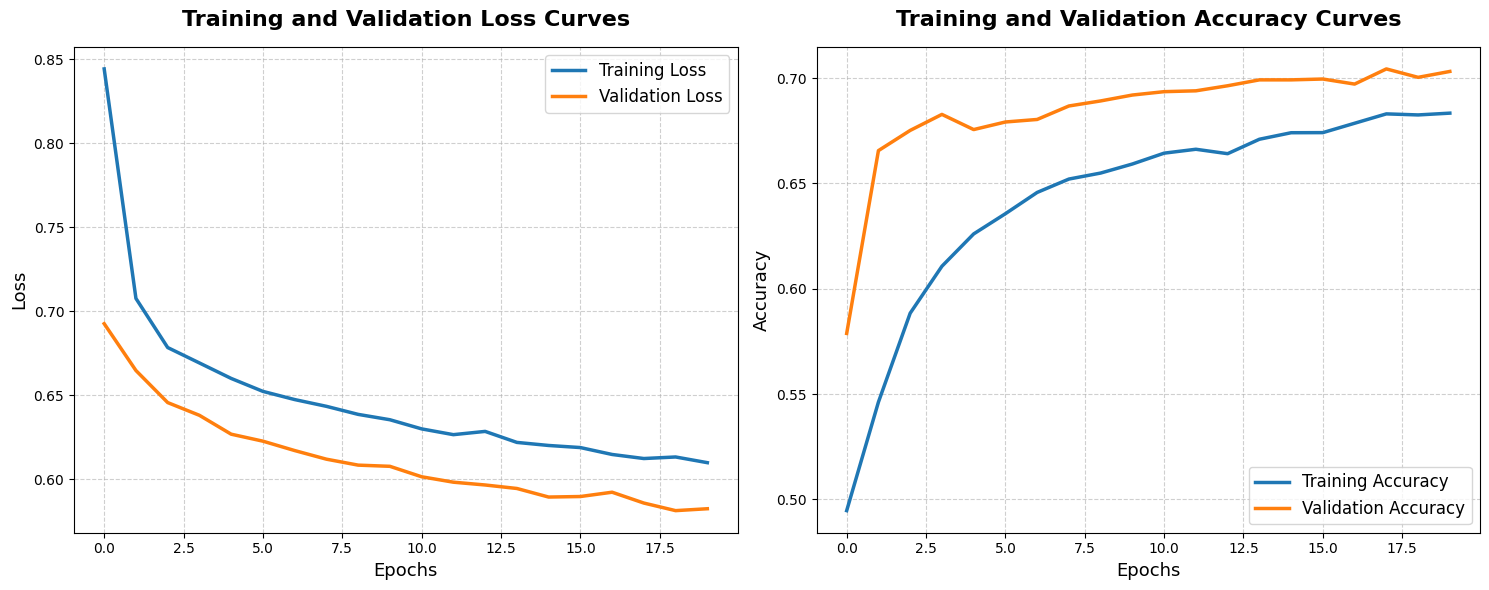

In [14]:
import matplotlib.pyplot as plt

# Plotting Training and Validation Loss & Accuracy in the requested theme
plt.figure(figsize=(15, 6))

# 1. Loss Curves
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2.5)
plt.title('Training and Validation Loss Curves', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Loss', fontsize=13)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Accuracy Curves
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2.5)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linewidth=2.5)
plt.title('Training and Validation Accuracy Curves', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Epochs', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.legend(fontsize=12, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [15]:
model.predict(["This is the worst movie I have ever seen",
              "An excellent movie that I enjoyed a lot",
              "how can one make such a horrible movie? there is no story, acting direction everything is very poor"])

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 26ms/step


array([[0.39841446],
       [0.5765797 ],
       [0.43258724]], dtype=float32)

In [16]:
model.predict(["An excellent movie that I enjoyed a lot"])

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 7ms/step


array([[0.5765797]], dtype=float32)